In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
# Read the csv file
df1 = pd.read_csv("SVMtrain.csv")

In [3]:
# Call the csv file
df1

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,Male,22.0,1,0,7.2500,3
1,2,1,1,female,38.0,1,0,71.2833,1
2,3,1,3,female,26.0,0,0,7.9250,3
3,4,1,1,female,35.0,1,0,53.1000,3
4,5,0,3,Male,35.0,0,0,8.0500,3
...,...,...,...,...,...,...,...,...,...
884,887,0,2,Male,27.0,0,0,13.0000,3
885,888,1,1,female,19.0,0,0,30.0000,3
886,889,0,3,female,60.0,1,2,23.4500,3
887,890,1,1,Male,26.0,0,0,30.0000,1


In [4]:
# Check wheather the Dataset is containing NaN values or not
df1.isna()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
884,False,False,False,False,False,False,False,False,False
885,False,False,False,False,False,False,False,False,False
886,False,False,False,False,False,False,False,False,False
887,False,False,False,False,False,False,False,False,False


In [5]:
# To sum all the NaN values
df1.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

In [6]:
# To get the basic information of the Dataset
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Sex          889 non-null    object 
 4   Age          889 non-null    float64
 5   SibSp        889 non-null    int64  
 6   Parch        889 non-null    int64  
 7   Fare         889 non-null    float64
 8   Embarked     889 non-null    int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 62.6+ KB


In [7]:
# To get the discription of the Dataset
df1.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,446.000000,0.382452,2.311586,35.686355,0.524184,0.382452,32.096681,2.535433
std,256.998173,0.486260,0.834700,17.756733,1.103705,0.806761,49.697504,0.792088
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000
25%,224.000000,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800,2.000000
50%,446.000000,0.000000,3.000000,32.000000,0.000000,0.000000,14.454200,3.000000
75%,668.000000,1.000000,3.000000,54.000000,1.000000,0.000000,31.000000,3.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,3.000000


In [8]:
# To know the top 5 passengers only
df1.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,Male,22.0,1,0,7.2500,3
1,2,1,1,female,38.0,1,0,71.2833,1
2,3,1,3,female,26.0,0,0,7.9250,3
3,4,1,1,female,35.0,1,0,53.1000,3
4,5,0,3,Male,35.0,0,0,8.0500,3


In [9]:
# To know the bottom 5 passengers
df1.tail() 

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
884,887,0,2,Male,27.0,0,0,13.00,3
885,888,1,1,female,19.0,0,0,30.00,3
886,889,0,3,female,60.0,1,2,23.45,3
887,890,1,1,Male,26.0,0,0,30.00,1
888,891,0,3,Male,32.0,0,0,7.75,2


In [10]:
# Create pivot table
pivot_table = pd.pivot_table(df1, values=['Survived', 'Age'], index= 'Sex', aggfunc= 'mean')
pivot_table = pivot_table.reset_index()
pivot_table

,Sex,Age,Survived
0,Male,37.017626,0.188908
1,female,33.224359,0.740385


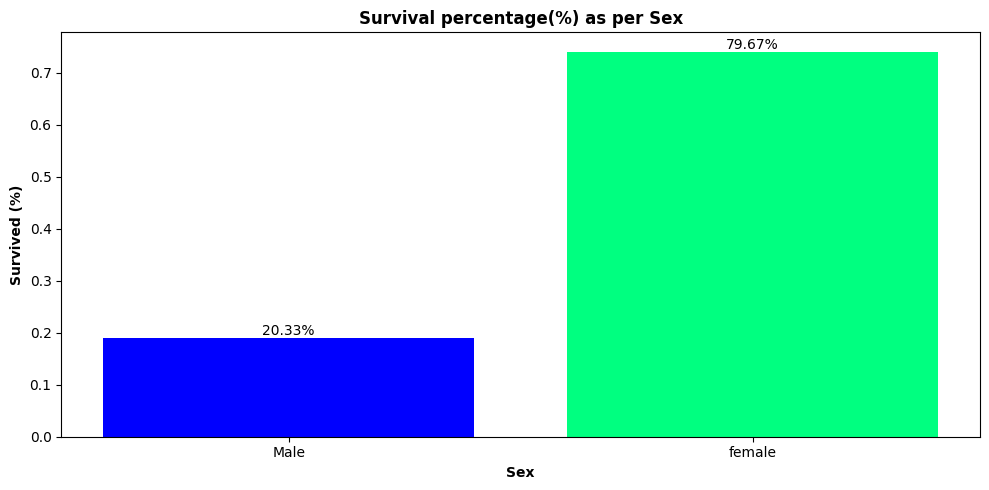

In [ ]:
# To know the percentage of sex that survived the most
total_survived = pivot_table['Survived'].sum()
plt.figure(figsize=(10, 5))
bars = plt.bar(pivot_table['Sex'], pivot_table['Survived'], color=plt.cm.winter(np.linspace(0, 1, len(pivot_table))))
plt.xlabel('Sex', fontweight='bold')
plt.ylabel('Survived (%)', fontweight='bold')
plt.title("Survival percentage(%) as per Sex", fontweight='bold')

# Adding data labels with percentages
for bar in bars:
    yval = bar.get_height()
    percent = (yval / total_survived) * 100
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f'{percent:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

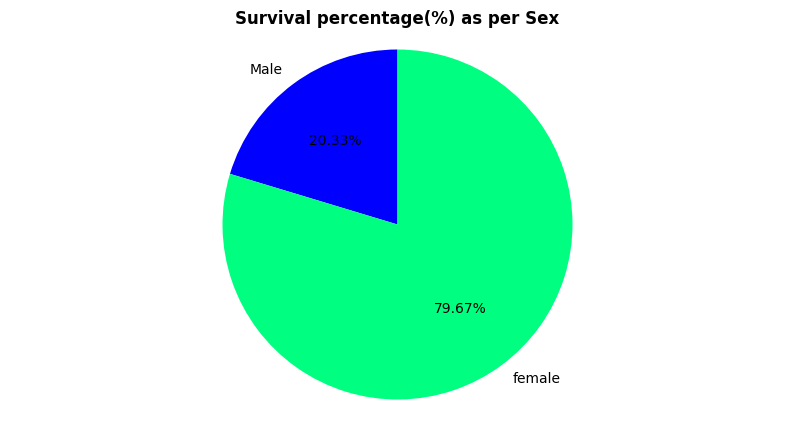

In [51]:
# Create a pie chart to know about the percentage of the survived sex
total_survived = pivot_table['Survived'].sum()
pivot_table['Percentage'] = (pivot_table['Survived'] / total_survived) * 100
plt.figure(figsize=(10, 5))
plt.pie(pivot_table['Survived'], labels=pivot_table['Sex'], autopct=lambda p: '{:.2f}%'.format(p), startangle=90, colors=plt.cm.winter(np.linspace(0, 1, len(pivot_table))))
plt.title("Survival percentage(%) as per Sex", fontweight='bold')
plt.axis('equal')
plt.show()

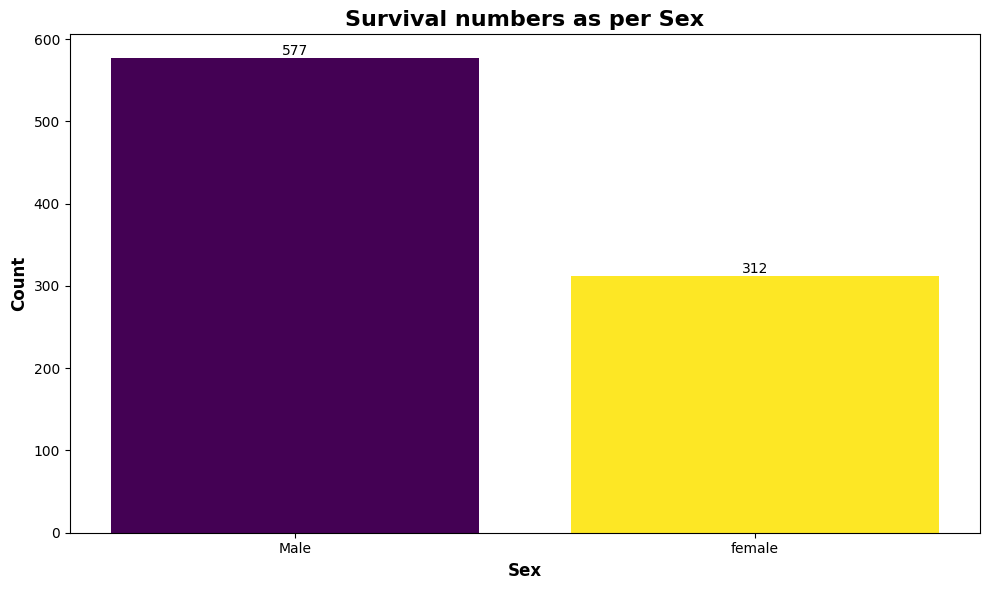

In [ ]:
# To know about the numbers of the survived sex 
sex_counts = df1['Sex'].value_counts()
plt.figure(figsize=(10, 6))
bars = plt.bar(sex_counts.index, sex_counts, color=plt.cm.viridis(np.linspace(0, 1, len(sex_counts))))
plt.xlabel('Sex', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Survival numbers as per Sex', fontsize=16, fontweight='bold')

# Adding data labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, yval, int(yval), ha='center', va='bottom')

plt.tight_layout()
plt.show()

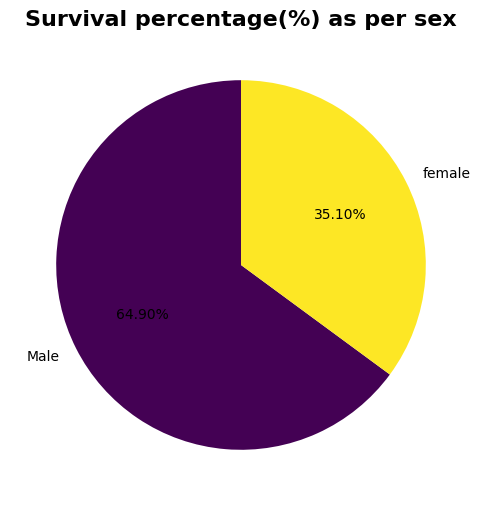

In [38]:
# Create pie chart for Survival percentage as per sex
sex_counts = df1['Sex'].value_counts()
plt.figure(figsize=(10, 6))
plt.pie(sex_counts, labels=sex_counts.index, autopct='%.2f%%', startangle=90, colors=plt.cm.viridis(np.linspace(0,1,len(sex_counts))))
plt.title('Survival percentage(%) as per sex', fontsize=16, fontweight='bold')
plt.show()